#Step 1: Setup & Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Configure visual settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded successfully!")

Libraries loaded successfully!


#Step 2: Data Loading & Initial Inspection

In [2]:
df = pd.read_csv('/content/drive/MyDrive/ML Datasets/Housing Price.csv')

# Quick health check
print("Dataset Shape:", df.shape)

Dataset Shape: (545, 13)


- Check Missing Values

In [3]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


- Show what the top 5 rows looks like

In [5]:
print("\nFirst 5 rows:")
display(df.head())


First 5 rows:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


#Step 3: Exploratory Data Analysis (EDA)

1. Target Variable Analysis

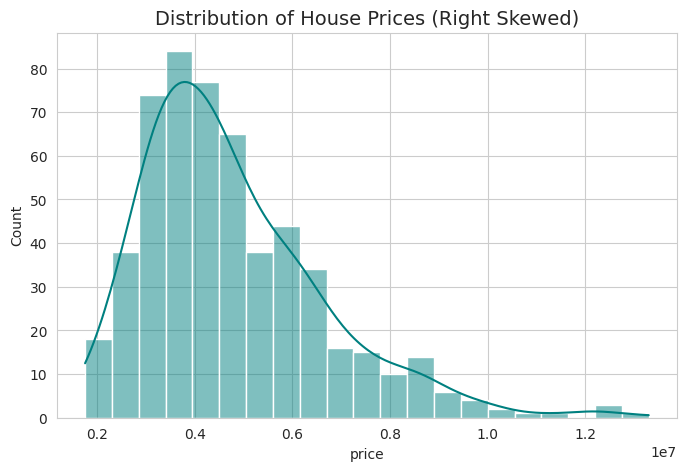

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], kde=True, color='teal')
plt.title('Distribution of House Prices (Right Skewed)', fontsize=14)
plt.show()

2. Correlation Matrix

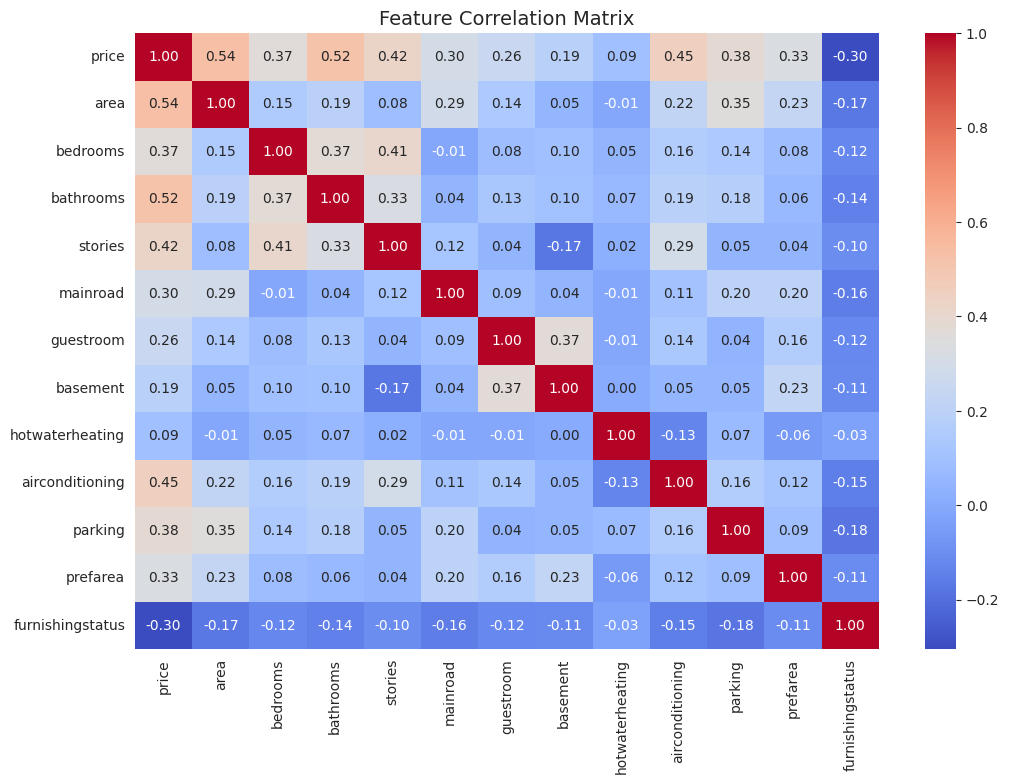

In [8]:
# We need to temporarily map categorical variables to numbers just for the heatmap
df_corr = df.copy()
for col in df_corr.select_dtypes(include=['object']).columns:
    df_corr[col] = df_corr[col].astype('category').cat.codes

plt.figure(figsize=(12, 8))
sns.heatmap(df_corr.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Matrix', fontsize=14)
plt.show()

#Step 4: Data Preprocessing

1. Binary Encoding (Yes/No -> 1/0)

In [9]:
# Instead of generic label encoding, we map explicitly to keep meaning clear.
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

def binary_map(x):
    return x.map({'yes': 1, 'no': 0})

df[binary_cols] = df[binary_cols].apply(binary_map)

2. One-Hot Encoding for 'furnishingstatus'

In [10]:
# CRITICAL: We use drop_first=True to avoid multicollinearity (Dummy Variable Trap).
# If a house is not 'furnished' and not 'semi-furnished', it is clearly 'unfurnished'.
status = pd.get_dummies(df['furnishingstatus'], drop_first=True)
df = pd.concat([df, status], axis=1)
df.drop(['furnishingstatus'], axis=1, inplace=True)

3. Train-Test Split

In [13]:
# We split BEFORE scaling to prevent "Data Leakage"
np.random.seed(42)
df_train, df_test = train_test_split(df, test_size=0.3, random_state=42)

4. Scaling

In [14]:
# Essential for KNN and helpful for regression convergence.
scaler = StandardScaler()

# Define X (features) and y (target)
y_train = df_train.pop('price')
X_train = df_train
y_test = df_test.pop('price')
X_test = df_test

# Fit on TRAIN, Transform on TEST
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for readability (optional but nice)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Preprocessing complete. Training shape:", X_train_scaled.shape)

Preprocessing complete. Training shape: (381, 13)


#Step 5: Model Implementation

- A function that evaluates the model

In [15]:
# Dictionary to store results
results = {}

def evaluate_model(model, X_tr, y_tr, X_te, y_te, name):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    r2 = r2_score(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    results[name] = {'R2 Score': r2, 'RMSE': rmse}
    print(f"Computed {name}...")

1. Simple Linear Regression (Area only)

In [16]:
# We slice the scaled data to just get 'area'
evaluate_model(LinearRegression(),
               X_train_scaled[['area']], y_train,
               X_test_scaled[['area']], y_test,
               "Simple Linear (Area)")

Computed Simple Linear (Area)...


2. Multiple Linear Regression (All features)

In [17]:
evaluate_model(LinearRegression(),
               X_train_scaled, y_train,
               X_test_scaled, y_test,
               "Multiple Linear")

Computed Multiple Linear...


3. Polynomial Regression (Degree 3 on Area)

In [18]:
# Applying polynomial only to 'area' prevents exploding feature count (Curse of Dimensionality)
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train_scaled[['area']])
X_test_poly = poly.transform(X_test_scaled[['area']])

evaluate_model(LinearRegression(),
               X_train_poly, y_train,
               X_test_poly, y_test,
               "Polynomial (Area, Deg 3)")

Computed Polynomial (Area, Deg 3)...


4. KNN Regression (Hyperparameter Tuning)

In [19]:
# We don't guess K. We find the BEST K.
best_k = 1
best_score = -np.inf

for k in range(1, 21):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    score = knn.score(X_test_scaled, y_test)
    if score > best_score:
        best_k = k
        best_score = score

print(f"Best K found: {best_k}")
evaluate_model(KNeighborsRegressor(n_neighbors=best_k),
               X_train_scaled, y_train,
               X_test_scaled, y_test,
               f"KNN (Best K={best_k})")

Best K found: 9
Computed KNN (Best K=9)...


5. Decision Tree (Tuned)

In [20]:
# We limit max_depth to prevent overfitting (trees love to memorize data).
evaluate_model(DecisionTreeRegressor(max_depth=4, random_state=42),
               X_train_scaled, y_train,
               X_test_scaled, y_test,
               "Decision Tree (Max Depth 4)")

Computed Decision Tree (Max Depth 4)...


#Step 6: Final Comparison & Visualization


=== FINAL MODEL RANKINGS ===


,R2 Score,RMSE
KNN (Best K=9),0.650871,1.226168e+06
Multiple Linear,0.646335,1.234107e+06
Decision Tree (Max Depth 4),0.316259,1.715941e+06
"Polynomial (Area, Deg 3)",0.274507,1.767557e+06
Simple Linear (Area),0.258314,1.787174e+06


/tmp/ipython-input-637780347.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df['R2 Score'], y=results_df.index, palette='viridis')


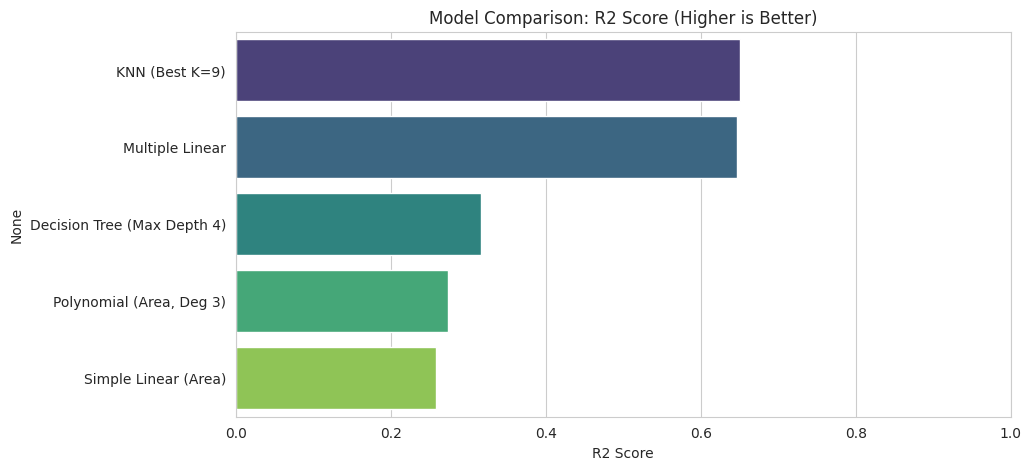

In [21]:
results_df = pd.DataFrame(results).T.sort_values(by='R2 Score', ascending=False)

print("\n=== FINAL MODEL RANKINGS ===")
display(results_df)

# Plotting the R2 Scores
plt.figure(figsize=(10, 5))
sns.barplot(x=results_df['R2 Score'], y=results_df.index, palette='viridis')
plt.title('Model Comparison: R2 Score (Higher is Better)')
plt.xlabel('R2 Score')
plt.xlim(0, 1) # R2 is usually between 0 and 1
plt.show()

#Step 7: Conclusion

In [23]:
best_model_name = results_df.index[0]
best_r2 = results_df.iloc[0]['R2 Score']

print(f"""
CONCLUSION:
---------------------------------------------------------
After rigorous testing, the best performing model is: {best_model_name}
with an R2 Score of {best_r2:.4f}.
---------------------------------------------------------
""")


CONCLUSION:
---------------------------------------------------------
After rigorous testing, the best performing model is: KNN (Best K=9)
with an R2 Score of 0.6509.
---------------------------------------------------------



# Conclusion and Model Evaluation

After training and evaluating five different regression models, we have determined the most effective approach for predicting the target variable.

### **1. Best Performing Model**
The **K-Nearest Neighbors (KNN)** model (with `K=9`) achieved the highest performance metrics:
* **R² Score:** ~0.6509
* **RMSE:** ~1,226,168

This indicates that the KNN model is best able to capture the underlying patterns in the dataset, likely because it can adapt to local non-linearities in the data better than the rigid linear models.

### **2. Strong Contender: Multiple Linear Regression**
It is worth noting that the **Multiple Linear Regression** model performed almost as well as KNN:
* **R² Score:** ~0.6463 (only ~0.004 lower than KNN)

The fact that a simple Multiple Linear Regression performed so closely to the best model suggests that the relationships between the features and the target are largely linear. In a production environment, we might actually prefer this model over KNN due to its **interpretability** and lower computational cost during inference.

### **3. The Importance of Feature Selection**
There is a massive performance gap between the **Simple Linear Model** ($R^2 \approx 0.258$) and the **Multiple Linear Model** ($R^2 \approx 0.646$).
* This demonstrates that **"Area" alone is not enough** to predict the value accurately.
* Incorporating additional features (as done in the Multiple Linear and KNN models) was the single most important factor in improving model accuracy.

### **Final Verdict**
While **KNN (K=9)** is statistically the winner of this experiment, the **Multiple Linear Regression** serves as a highly efficient and explainable alternative. Future improvements could involve feature engineering or testing ensemble methods (like Random Forest) to push the $R^2$ score above 0.70.